In [21]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

In [22]:
import sys
print(sys.executable)

/Users/beracevik/Desktop/X-Ray-Chest-Anomaly-Detection/X-Ray-Chest-Anomaly-Detection/venv/bin/python


In [23]:
train_dir = "ChestXray_Classification/train"
valid_dir = "ChestXray_Classification/valid"
test_dir = "ChestXray_Classification/test"

In [24]:
import os

train_normal = len(os.listdir(train_dir + "/0"))
train_abnormal = len(os.listdir(train_dir + "/1"))

valid_normal = len(os.listdir(valid_dir + "/0"))
valid_abnormal = len(os.listdir(valid_dir + "/1"))

test_normal = len(os.listdir(test_dir + "/0"))
test_abnormal = len(os.listdir(test_dir + "/1"))

print("TRAIN")
print("Normal:", train_normal)
print("Abnormal:", train_abnormal)

print("\nVALID")
print("Normal:", valid_normal)
print("Abnormal:", valid_abnormal)

print("\nTEST")
print("Normal:", test_normal)
print("Abnormal:", test_abnormal)

TRAIN
Normal: 4277
Abnormal: 4277

VALID
Normal: 535
Abnormal: 535

TEST
Normal: 535
Abnormal: 535


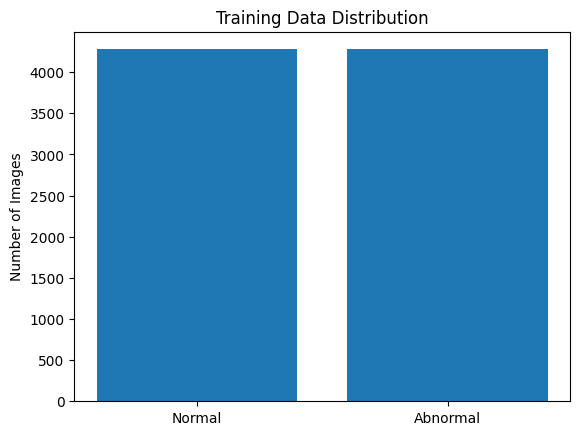

In [25]:
classes = ['Normal', 'Abnormal']
counts = [train_normal, train_abnormal]

plt.bar(classes, counts)
plt.title("Training Data Distribution")
plt.ylabel("Number of Images")
plt.show()

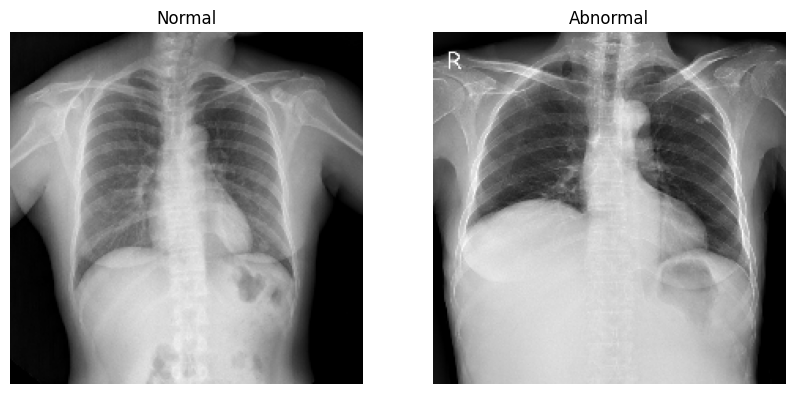

In [26]:
from tensorflow.keras.preprocessing import image

plt.figure(figsize=(10,5))

normal_img_path = train_dir + "/0/" + os.listdir(train_dir + "/0")[0]
abnormal_img_path = train_dir + "/1/" + os.listdir(train_dir + "/1")[0]

normal_img = image.load_img(normal_img_path, target_size=(224,224))
abnormal_img = image.load_img(abnormal_img_path, target_size=(224,224))

plt.subplot(1,2,1)
plt.imshow(normal_img)
plt.title("Normal")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(abnormal_img)
plt.title("Abnormal")
plt.axis("off")

plt.show()

Abnormal images appear to contain denser white regions compared to normal samples.

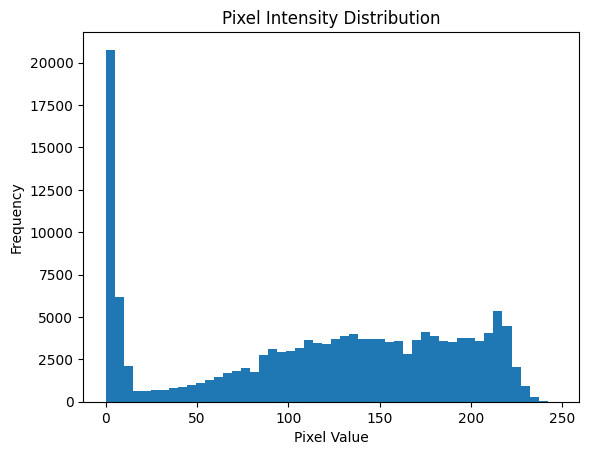

In [27]:
img_array = image.img_to_array(normal_img)

plt.hist(img_array.flatten(), bins=50)
plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()

histogram sola yakınsa → dark image
sağdaysa → bright image
çok dar dağılımsa → düşük contrast

In [28]:
import cv2

In [29]:
import sys
print(sys.executable)

/Users/beracevik/Desktop/X-Ray-Chest-Anomaly-Detection/X-Ray-Chest-Anomaly-Detection/venv/bin/python


In [39]:
import cv2
import numpy as np
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

In [40]:
def medic_clahe_preprocessing(img):
    img_uint8 = img.astype('uint8')
    gray = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    clahe_img = clahe.apply(gray)
    img_out = cv2.cvtColor(clahe_img, cv2.COLOR_GRAY2RGB)
    return img_out.astype('float32')

In [41]:
# --- ADIM 2: GELİŞMİŞ VERİ ÜRETEÇLERİ VE ARTIRIM (AUGMENTATION) ---
img_size = (224, 224)
batch_size = 32

train_generator = ImageDataGenerator(
    rescale=1./255,
    preprocessing_function=medic_clahe_preprocessing,
    rotation_range=15,
    horizontal_flip=True,
    fill_mode='nearest'
)

valid_generator = ImageDataGenerator(rescale=1./255, preprocessing_function=medic_clahe_preprocessing)
test_generator = ImageDataGenerator(rescale=1./255, preprocessing_function=medic_clahe_preprocessing)

train_data = train_generator.flow_from_directory(
    train_dir, target_size=img_size, batch_size=batch_size, class_mode='binary'
)
valid_data = valid_generator.flow_from_directory(
    valid_dir, target_size=img_size, batch_size=batch_size, class_mode='binary'
)
test_data = test_generator.flow_from_directory(
    test_dir, target_size=img_size, batch_size=batch_size, class_mode='binary', shuffle=False
)

Found 8554 images belonging to 2 classes.
Found 1070 images belonging to 2 classes.
Found 1070 images belonging to 2 classes.


In [42]:
# --- ADIM 3: TRANSFER LEARNING (RESNET50 MİMARİSİ) ---
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False 

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.inputs, outputs=predictions)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 9s 0us/step


In [43]:
# --- ADIM 4: MEDİKAL METRİKLERLE DERLEME (COMPILE) ---
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(name='recall'), tf.keras.metrics.AUC(name='auc')]
)

In [44]:
# --- ADIM 5: MODELİ EĞİTME ---
history = model.fit(
    train_data,
    validation_data=valid_data,
    epochs=10
)

Epoch 1/10
268/268 ━━━━━━━━━━━━━━━━━━━━ 207s 765ms/step - accuracy: 0.5309 - auc: 0.5437 - loss: 0.7043 - recall: 0.5015 - val_accuracy: 0.5841 - val_auc: 0.6215 - val_loss: 0.6780 - val_recall: 0.6579
Epoch 2/10
268/268 ━━━━━━━━━━━━━━━━━━━━ 208s 776ms/step - accuracy: 0.5567 - auc: 0.5908 - loss: 0.6811 - recall: 0.4669 - val_accuracy: 0.5935 - val_auc: 0.6337 - val_loss: 0.6710 - val_recall: 0.6879
Epoch 3/10
268/268 ━━━━━━━━━━━━━━━━━━━━ 216s 805ms/step - accuracy: 0.5783 - auc: 0.6171 - loss: 0.6711 - recall: 0.5670 - val_accuracy: 0.5944 - val_auc: 0.6363 - val_loss: 0.6639 - val_recall: 0.6766
Epoch 4/10
268/268 ━━━━━━━━━━━━━━━━━━━━ 213s 796ms/step - accuracy: 0.5933 - auc: 0.6289 - loss: 0.6644 - recall: 0.6509 - val_accuracy: 0.5972 - val_auc: 0.6453 - val_loss: 0.6517 - val_recall: 0.6897
Epoch 5/10
268/268 ━━━━━━━━━━━━━━━━━━━━ 213s 795ms/step - accuracy: 0.6031 - auc: 0.6338 - loss: 0.6595 - recall: 0.7042 - val_accuracy: 0.6112 - val_auc: 0.6542 - val_loss: 0.6471 - val_recal